# Example: Geo-intervention Modelling Framework

Demonstrates a simple example of the geo-intervention modelling framework.

## Libraries

In [55]:
import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon

## Spatial Data Component

In [56]:
# Create locations as geometry
point = Point(43, -79)
line = LineString([(45, -79), (44, -78)])
polygon = Polygon([(46, -77), (47, -80), (48, -75)])

# Create initial spatial data
data = gpd.GeoDataFrame(
    {
        'i': [1, 2, 3],
        'Xi1': [1.25, 2.55, 5.75],
        'Xi2': [2, 4, 6],
        'Xi3': [4, 0, 16],
        'Li': [point, line, polygon]
    },
    geometry = 'Li'
)

# Spatial data engineering

# Calc new non spatial var
data['Xi1 + Xi2'] = data.Xi1 + data.Xi2

# Calc spatial var for nearest location i
data['Nearesti'] = data.Li.apply(
    lambda Li: data.distance(Li)
).apply(
    lambda Li: data.loc[Li[Li > 0].idxmin(), 'i']
)

# Calc spatial var for length of location geom
data['Length(Li)'] = data.Li.length

# Calc spatial var for type of location geom
data['Type(Li)'] = data.Li.type.replace('LineString', 'Line')

# Move location to the end
data = data[[c for c in data.columns if c != 'Li'] + ['Li']]

# Display spatial data results as table
data

,i,Xi1,Xi2,Xi3,Xi1 + Xi2,Nearesti,Length(Li),Type(Li),Li
0,1,1.25,2,4,3.25,2,0.000000,Point,POINT (43.00000 -79.00000)
1,2,2.55,4,0,6.55,1,1.414214,Line,"LINESTRING (45.00000 -79.00000, 44.00000 -78.0..."
2,3,5.75,6,16,11.75,2,11.089724,Polygon,"POLYGON ((46.00000 -77.00000, 47.00000 -80.000..."


/var/folders/lg/1tfppccd38s1sn9w5z9g_mcm0000gn/T/ipykernel_1311/114793841.py:6: MatplotlibDeprecationWarning: The 's' parameter of annotate() has been renamed 'text' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  plt.annotate(


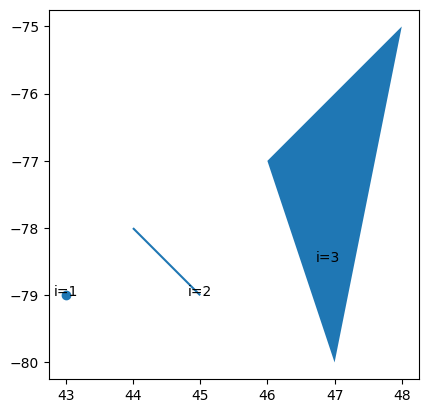

In [57]:
# Display spatial data results as map
data.plot()

# Add labels for index i
for i, row in data.iterrows():
    plt.annotate(
        s = 'i=' + str(row['i']),
        xy = row['Li'].representative_point().coords[0],
        horizontalalignment = 'center'
    )

## Outcome Modelling Component

In [58]:
# Prepare outcome modelling data
model_data = pd.DataFrame(data.drop(columns = 'Li'))

# Select outcome var y
model_data['Yi = Xi3'] = model_data.pop('Xi3')

# Create simple model as func f
# The model represents the eq: Y^i = Xi1 + Xi2 * Nearest(Length(Li))
def model(input_data):
    near_len = input_data\
        .iloc[input_data['Nearesti'] - 1]['Length(Li)']\
        .reset_index(drop = True)
    out = input_data['Xi1 + Xi2'] * near_len
    return out

# Apply model to get the estimated outcome yhat
model_data['Y^i'] = model(model_data)

# Calc the error
model_data['ei = Yi - Y^i'] = abs(model_data['Yi = Xi3'] - model_data['Y^i'])

# Display outcome modelling results as table
model_data

,i,Xi1,Xi2,Xi1 + Xi2,Nearesti,Length(Li),Type(Li),Yi = Xi3,Y^i,ei = Yi - Y^i
0,1,1.25,2,3.25,2,0.000000,Point,4,4.596194,0.596194
1,2,2.55,4,6.55,1,1.414214,Line,0,0.000000,0.000000
2,3,5.75,6,11.75,2,11.089724,Polygon,16,16.617009,0.617009


## Geo-intervention Generation Component

In [64]:
# Get data for one opt iteration for i = 1 and 2
opt_data = model_data.copy(deep = True)\
    .drop(['Yi = Xi3', 'ei = Yi - Y^i'], axis = 1)

# Add cols for actions 4 and 5
opt_data['Ai4'] = [7, -3, 0]
opt_data['Ai5'] = [2, -1, 0]

# Apply actions to var 1 and 2 for i = 1 and 2
opt_data['Xi1 + Xi2'] += opt_data['Ai4']
opt_data['Length(Li)'] += opt_data['Ai5']

# Filter for i = 1 and 2
opt_data = opt_data[opt_data.i.isin([1, 2])]

# Est outcome from actions
opt_data['Y^i'] = model(opt_data)

# Init geoint results with original vars
geoint_data = pd.DataFrame()
geoint_data['i'] = model_data['i']
geoint_data['Xi1 + Xi2'] = model_data['Xi1 + Xi2']
geoint_data['Length(Li)'] = model_data['Length(Li)']

# Set geoint results to i = 1 and 2
geoint_data = geoint_data[geoint_data.i.isin([1,2])]

# Add opt results to geoint results
geoint_data['Ai4'] = opt_data['Ai4']
geoint_data['Ai5'] = opt_data['Ai5']
geoint_data['X^i4 = (Xi1 + Xi2) + Ai4'] = opt_data['Xi1 + Xi2']
geoint_data['X^i5 = Length(Li) + Ai5'] = opt_data['Length(Li)']
geoint_data['Y^i = f(X^i1 ... X^i5)'] = opt_data['Y^i']

# Display geoint results as table
geoint_data

,i,Xi1 + Xi2,Length(Li),Ai4,Ai5,X^i4 = (Xi1 + Xi2) + Ai4,X^i5 = Length(Li) + Ai5,Y^i = f(X^i1 ... X^i5)
0,1,3.25,0.000000,7,2,10.25,2.000000,4.245689
1,2,6.55,1.414214,-3,-1,3.55,0.414214,7.100000
